# Введение в RL и пакет Gymnasium

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* https://gymnasium.farama.org/
* https://pypi.org/project/ufal.pybox2d/
* https://gymnasium.farama.org/tutorials/gymnasium_basics/environment_creation/
* https://gymnasium.farama.org/api/spaces/fundamental/
* https://gymnasium.farama.org/environments/toy_text/blackjack/

## Задачи для совместного разбора

1. Рассмотрите пример создания окружения `gymnasium` и основные этапы взаимодействия с этим окружением.
<img src="https://gymnasium.farama.org/_images/AE_loop.png" width="300"/>

In [12]:
import gymnasium as gym
import random
from gymnasium import spaces
import numpy as np

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Создайте окружение `Blackjack-v1`. Сыграйте `N=10000` игр, выбирая действие случайным образом. Посчитайте и выведите на экран долю выигранных игр.

- [ ] Проверено на семинаре

In [6]:
# Создаем окружение Blackjack-v1
env = gym.make("Blackjack-v1")


# Счетчик для выигранных игр
wins = 0
N = 10000  # Количество игр

# Симуляция игр
for _ in range(N):
    state, _ = env.reset()  # Получаем начальное состояние
    done = False
    
    while not done:
        action = random.choice([0, 1])
        next_state, reward, done, truncated, info = env.step(action)  # Распаковываем 5 значений

    if reward > 0:
        wins += 1

# Выводим долю выигранных игр
win_rate = wins / N
print(f"Доля выигранных игр: {win_rate:.4f}")

Доля выигранных игр: 0.2820


<p class="task" id="2"></p>

2\. Создайте окружение `Blackjack-v1`. Предложите стратегию, которая позволит, в среднем, выигрывать чаще, чем случайный выбор действия. Реализуйте эту стратегию и сыграйте `N=10000` игр, выбирая действие согласно этой стратегии. Посчитайте и выведите на экран долю выигранных игр.

- [ ] Проверено на семинаре

In [7]:
# Создаем окружение Blackjack-v1
env = gym.make("Blackjack-v1")

# Счетчик для выигранных игр
wins = 0
N = 10000  # Количество игр

# Функция для принятия решения по стратегии
def advanced_strategy(state):
    player_sum, dealer_card, usable_ace = state

    # Если у нас две одинаковые карты, пытаемся разделить
    if player_sum == 8 or player_sum == 16:  # 8-8 или 7-7
        if dealer_card <= 6:
            return 0  # Stand (лучше разделить)
        else:
            return 1  # Hit (лучше не разделять)

    # Если у нас есть туз (usable_ace) и сумма <= 11, всегда берем карту
    if usable_ace and player_sum <= 11:
        return 1  # Hit

    # Если сумма карт игрока больше или равна 17, остаемся
    if player_sum >= 17:
        return 0  # Stand

    # Если сумма карт от 12 до 16, и карта дилера слабая (2-6), остаемся
    if 12 <= player_sum <= 16:
        if dealer_card <= 6:
            return 0  # Stand
        else:
            return 1  # Hit

    # Если сумма меньше 12, всегда берем карту
    return 1  # Hit

# Симуляция игр с улучшенной стратегией
for _ in range(N):
    state, _ = env.reset()  # Получаем начальное состояние
    done = False
    
    while not done:
        action = advanced_strategy(state)  # Применяем стратегию
        next_state, reward, done, truncated, info = env.step(action)  # Выполняем действие
        
    if reward > 0:
        wins += 1

# Выводим долю выигранных игр
win_rate = wins / N
print(f"Доля выигранных игр: {win_rate:.4f}")


Доля выигранных игр: 0.2723


<p class="task" id="3"></p>

3\. Создайте окружение для игры в крестики-нолики, реализовав интерфейс `gym.Env`. Решение должно удовлетворять следующим условиям:
* для создания пространства состояний используется `spaces.Box`;
* для создания пространства действий используется `spaces.MultiDiscrete`;
* игра прекращается, если:
    - нет возможности сделать ход;
    - игрок пытается отметить уже выбранную ячейку.
* после каждого хода игрок получает награду:
    - 0, если игра не закончена;
    - 1, если игрок выиграл;
    - -1, если игрок проиграл.
* стратегию выбора действия для второго игрока (машины) определите самостоятельно.

Стратегия поведения машины является частью окружения и должна быть реализована внутри него. Сделайте все соответствующие переменные и методы приватными (названия всех переменных начинаются с `__`), подчеркнув, что у пользователя не должно быть к ним доступа извне. 

Сыграйте одну игру, выбирая действия случайным образом. Выведите на экран состояние окружения после каждого хода и итоговую награду пользователя за сессию.

- [ ] Проверено на семинаре

In [8]:
class TicTacToeEnv(gym.Env):
    def __init__(self):
        super(TicTacToeEnv, self).__init__()

        # Пространство состояний: одномерный массив 9 элементов (3x3 поле)
        self.observation_space = spaces.Box(low=-1, high=1, shape=(9,), dtype=np.int8)
        
        # Пространство действий: от 0 до 8 (индексы клеток на поле)
        self.action_space = spaces.Discrete(9)
        
        # Инициализация состояния
        self.__state = np.zeros(9, dtype=np.int8)  # Изначально поле пустое
        self.__done = False
        self.__current_player = 1  # Начинает игрок 1 (крестик)
    
    def reset(self):
        """Сброс состояния игры"""
        self.__state = np.zeros(9, dtype=np.int8)  # Сбросить поле
        self.__done = False
        self.__current_player = 1  # Начинает игрок 1
        return self.__state
    
    def step(self, action):
        """Шаг игры"""
        if self.__done:
            return self.__state, 0, True, {}

        action = action  # action — это просто число от 0 до 8
        
        # Проверка на уже занятое место
        if self.__state[action] != 0:
            return self.__state, -1, False, {}  # Возвращаем штраф, но не завершаем игру (некорректный ход)
        
        # Совершаем ход
        self.__state[action] = self.__current_player
        
        # Проверяем, не победил ли кто-то
        if self.__check_winner(self.__current_player):
            self.__done = True
            return self.__state, 1, True, {}  # Игрок победил
        
        # Проверяем на ничью (если нет пустых клеток)
        if np.all(self.__state != 0):  # Если нет пустых клеток
            self.__done = True
            return self.__state, 0, True, {}  # Ничья
        
        # Меняем игрока
        self.__current_player = -self.__current_player
        
        return self.__state, 0, False, {}  # Игра продолжается

    def __check_winner(self, player):
        """Проверка победителя"""
        # Возможные линии победы (индексы на поле 3x3)
        winning_combinations = [
            [0, 1, 2],  # 1-я строка
            [3, 4, 5],  # 2-я строка
            [6, 7, 8],  # 3-я строка
            [0, 3, 6],  # 1-й столбец
            [1, 4, 7],  # 2-й столбец
            [2, 5, 8],  # 3-й столбец
            [0, 4, 8],  # Диагональ
            [2, 4, 6]   # Диагональ
        ]
        for combo in winning_combinations:
            if np.all(self.__state[combo] == player):
                return True
        return False

    def render(self):
        """Отображение текущего состояния игры"""
        board = self.__state.reshape((3, 3))
        for row in board:
            print(' '.join(['X' if cell == 1 else 'O' if cell == -1 else '.' for cell in row]))
        print()

    def __get_best_move(self):
        """Стратегия для второго игрока (машины): выбирает лучший ход"""
        # 1. Проверка на победу для машины (игрока -1)
        for i in range(9):
            if self.__state[i] == 0:
                self.__state[i] = -1
                if self.__check_winner(-1):
                    self.__state[i] = 0
                    return i
                self.__state[i] = 0

        # 2. Блокировка победы для игрока (игрока 1)
        for i in range(9):
            if self.__state[i] == 0:
                self.__state[i] = 1
                if self.__check_winner(1):
                    self.__state[i] = 0
                    return i
                self.__state[i] = 0

        # 3. Центр
        if self.__state[4] == 0:
            return 4
        
        # 4. Углы
        corners = [0, 2, 6, 8]
        for corner in corners:
            if self.__state[corner] == 0:
                return corner
        
        # 5. Стороны
        sides = [1, 3, 5, 7]
        for side in sides:
            if self.__state[side] == 0:
                return side
        
        return np.random.choice(np.where(self.__state == 0)[0])  # Если нет других вариантов, выбираем случайную пустую клетку

    def close(self):
        pass

In [13]:
# Инициализация окружения
env = TicTacToeEnv()

# Сбросим состояние игры
state = env.reset()

done = False
total_reward = 0

# Играем 1 раунд
while not done:
    # Игрок 1 (крестик): выбираем случайное действие
    action = env.action_space.sample()
    print(f"Игрок 1 выбирает действие: {action}")
    state, reward, done, info = env.step([action])
    total_reward += reward
    
    # Отображаем состояние после хода
    env.render()

    if done:
        print(f"Игра завершена! Итоговая награда: {total_reward}")
        break

    # Игрок 2 (машина): выбираем ход для машины
    print(f"Игрок 2 (машина) делает ход...")
    state, reward, done, info = env.step([0])  # Машина делает ход на месте 0
    total_reward += reward
    
    # Отображаем состояние после хода
    env.render()

    if done:
        print(f"Игра завершена! Итоговая награда: {total_reward}")
        break


Игрок 1 выбирает действие: 5
. . .
. . X
. . .

Игрок 2 (машина) делает ход...
O . .
. . X
. . .

Игрок 1 выбирает действие: 2
O . X
. . X
. . .

Игрок 2 (машина) делает ход...
O . X
. . X
. . .

Игрок 1 выбирает действие: 3
O . X
O . X
. . .

Игрок 2 (машина) делает ход...
O . X
O . X
. . .

Игрок 1 выбирает действие: 1
O X X
O . X
. . .

Игрок 2 (машина) делает ход...
O X X
O . X
. . .

Игрок 1 выбирает действие: 8
O X X
O . X
. . O

Игрок 2 (машина) делает ход...
O X X
O . X
. . O

Игрок 1 выбирает действие: 8
O X X
O . X
. . O

Игрок 2 (машина) делает ход...
O X X
O . X
. . O

Игрок 1 выбирает действие: 5
O X X
O . X
. . O

Игрок 2 (машина) делает ход...
O X X
O . X
. . O

Игрок 1 выбирает действие: 1
O X X
O . X
. . O

Игрок 2 (машина) делает ход...
O X X
O . X
. . O

Игрок 1 выбирает действие: 7
O X X
O . X
. X O

Игрок 2 (машина) делает ход...
O X X
O . X
. X O

Игрок 1 выбирает действие: 3
O X X
O . X
. X O

Игрок 2 (машина) делает ход...
O X X
O . X
. X O

Игрок 1 выбирает дей

<p class="task" id="4"></p>

4\. Предложите стратегию (в виде алгоритма без использования методов машинного обучения), которая позволит, в среднем, выигрывать в крестики-нолики чаще, чем случайный выбор действия. Реализуйте эту стратегию и сыграйте игру, выбирая действия согласно этой стратегии. Выведите на экран состояние окружения после каждого хода и итоговую награду пользователя за сессию.

- [ ] Проверено на семинаре

In [14]:
from gymnasium import spaces
import numpy as np

class TicTacToeEnv(gym.Env):
    def __init__(self):
        super(TicTacToeEnv, self).__init__()

        # Пространство состояний: одномерный массив 9 элементов (3x3 поле)
        self.observation_space = spaces.Box(low=-1, high=1, shape=(9,), dtype=np.int8)
        
        # Пространство действий: от 0 до 8 (индексы клеток на поле)
        self.action_space = spaces.Discrete(9)
        
        # Инициализация состояния
        self.state = np.zeros(9, dtype=np.int8)  # Изначально поле пустое
        self.done = False
        self.current_player = 1  # Начинает игрок 1 (крестик)
    
    def reset(self):
        """Сброс состояния игры"""
        self.state = np.zeros(9, dtype=np.int8)  # Сбросить поле
        self.done = False
        self.current_player = 1  # Начинает игрок 1
        return self.state
    
    def step(self, action):
        """Шаг игры"""
        if self.done:
            return self.state, 0, True, {}

        action = action  # action — это просто число от 0 до 8
        
        # Проверка на уже занятое место
        if self.state[action] != 0:
            return self.state, -1, False, {}  # Возвращаем штраф, но не завершаем игру (некорректный ход)
        
        # Совершаем ход
        self.state[action] = self.current_player
        
        # Проверяем, не победил ли кто-то
        if self.__check_winner(self.current_player):
            self.done = True
            return self.state, 1, True, {}  # Игрок победил
        
        # Проверяем на ничью (если нет пустых клеток)
        if np.all(self.state != 0):  # Если нет пустых клеток
            self.done = True
            return self.state, 0, True, {}  # Ничья
        
        # Меняем игрока
        self.current_player = -self.current_player
        
        return self.state, 0, False, {}  # Игра продолжается

    def __check_winner(self, player):
        """Проверка победителя"""
        # Возможные линии победы (индексы на поле 3x3)
        winning_combinations = [
            [0, 1, 2],  # 1-я строка
            [3, 4, 5],  # 2-я строка
            [6, 7, 8],  # 3-я строка
            [0, 3, 6],  # 1-й столбец
            [1, 4, 7],  # 2-й столбец
            [2, 5, 8],  # 3-й столбец
            [0, 4, 8],  # Диагональ
            [2, 4, 6]   # Диагональ
        ]
        for combo in winning_combinations:
            if np.all(self.state[combo] == player):
                return True
        return False

    def render(self):
        """Отображение текущего состояния игры"""
        board = self.state.reshape((3, 3))
        for row in board:
            print(' '.join(['X' if cell == 1 else 'O' if cell == -1 else '.' for cell in row]))
        print()

    def get_best_move(self):
        """Стратегия для второго игрока (машины): выбирает лучший ход"""
        # 1. Проверка на победу для машины (игрока -1)
        for i in range(9):
            if self.state[i] == 0:
                self.state[i] = -1
                if self.__check_winner(-1):
                    self.state[i] = 0
                    return i
                self.state[i] = 0

        # 2. Блокировка победы для игрока (игрока 1)
        for i in range(9):
            if self.state[i] == 0:
                self.state[i] = 1
                if self.__check_winner(1):
                    self.state[i] = 0
                    return i
                self.state[i] = 0

        # 3. Центр
        if self.state[4] == 0:
            return 4
        
        # 4. Углы
        corners = [0, 2, 6, 8]
        for corner in corners:
            if self.state[corner] == 0:
                return corner
        
        # 5. Стороны
        sides = [1, 3, 5, 7]
        for side in sides:
            if self.state[side] == 0:
                return side
        
        return np.random.choice(np.where(self.state == 0)[0])  # Если нет других вариантов, выбираем случайную пустую клетку

    def close(self):
        pass

In [15]:
# Играем в игру с использованием стратегии
env = TicTacToeEnv()

# Инициализация
state = env.reset()
done = False
reward = 0
total_reward = 0

# Игрок 1 (крестик) играет с машиной (нолик)
while not done:
    print("Текущее состояние игры:")
    env.render()

    if env.current_player == 1:
        # Игрок 1 делает ход (случайный выбор или по стратегии)
        action = np.random.choice(np.where(state == 0)[0])  # Игрок 1 выбирает случайную пустую клетку
    else:
        # Игрок 2 (машина) делает ход согласно стратегии
        action = env.get_best_move()

    # Делаем шаг в игре
    state, reward, done, _ = env.step(action)
    total_reward += reward

# Выводим итог
print("Игра завершена!")
env.render()
print(f"Итоговая награда за сессию: {total_reward}")

Текущее состояние игры:
. . .
. . .
. . .

Текущее состояние игры:
. . .
. . X
. . .

Текущее состояние игры:
. . .
. O X
. . .

Текущее состояние игры:
. . .
. O X
. . X

Текущее состояние игры:
. . O
. O X
. . X

Текущее состояние игры:
. . O
. O X
. X X

Игра завершена!
. . O
. O X
O X X

Итоговая награда за сессию: 1


<p class="task" id="5"></p>

5\. Создайте окружение `MountainCar-v0`. Проиграйте 10 эпизодов и сохраните на диск файл с записью каждого пятого эпизода. Для записи видео воспользуйтесь обёрткой `RecordVideo`. Вставьте скриншот, на котором видно, что файлы были созданы.

- [ ] Проверено на семинаре

In [18]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import os
import cupy as cp  # Импортируем CuPy

# Создаём директорию для записи видео, если её ещё нет
video_dir = 'videos'
if not os.path.exists(video_dir):
    os.makedirs(video_dir)

# Создаём окружение с render_mode='rgb_array'
env = gym.make('MountainCar-v0', render_mode='rgb_array')

# Оборачиваем окружение в RecordVideo
env = RecordVideo(env, video_dir, episode_trigger=lambda x: x % 5 == 0)

# Играем 10 эпизодов
for episode in range(10):
    state, info = env.reset()
    done = False
    total_reward = 0
    while not done:
        action = env.action_space.sample()  # Случайный выбор действия
        state, reward, done, truncated, info = env.step(action)
        total_reward += reward
        
        # Используем CuPy для обработки состояния на GPU
        state_gpu = cp.asarray(state)  # Преобразуем state в массив CuPy на GPU
        # Например, можно выполнить какую-то операцию на GPU (например, квадрат каждого элемента)
        state_gpu = cp.square(state_gpu)

    print(f"Эпизод {episode + 1}: Награда = {total_reward}")

# Закрываем окружение после игры
env.close()

Эпизод 1: Награда = -10761.0
Эпизод 2: Награда = -8494.0
Эпизод 3: Награда = -24809.0
Эпизод 4: Награда = -2901.0
Эпизод 5: Награда = -29403.0
Эпизод 6: Награда = -42221.0
Эпизод 7: Награда = -65315.0
Эпизод 8: Награда = -27139.0
Эпизод 9: Награда = -25076.0
Эпизод 10: Награда = -33025.0


![Screenshot 2024-12-19 134908.png](<attachment:Screenshot 2024-12-19 134908.png>)
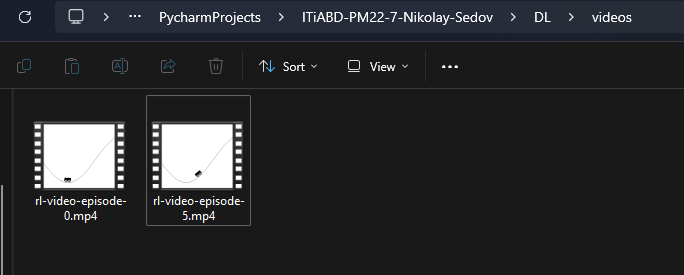

## Обратная связь
- [ ] Хочу получить обратную связь по решению